**LIBRARIES**

In [ ]:
# ======================================
# SECTION A: Imports and Setup
# ======================================

import os
import warnings
warnings.filterwarnings("ignore")

import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM, GRU, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam

import joblib

**DRIVE MOUNT**

In [55]:
# ======================================
# STEP 0: Mount Google Drive
# ======================================

drive.mount('/content/drive')

unpivoted_path = "/content/drive/MyDrive/Unpivoted.parquet"
print("Dataset found:", os.path.exists(unpivoted_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found: True


**MEMORY LOADING**

In [ ]:
# ======================================
# STEP 1: Load memory-safe experimental data
# ======================================

pq_file = pq.ParquetFile(unpivoted_path)

df_list = []
batch_size = 5000
max_batches = 100   # safe for Colab
selected_column = 'aggregated_stats_value'

for i, batch in enumerate(pq_file.iter_batches(batch_size=batch_size)):
    df_batch = batch.to_pandas()

    if selected_column in df_batch.columns:
        df_batch = df_batch[[selected_column]].dropna()

        if not df_batch.empty:
            df_list.append(df_batch)

    if i + 1 >= max_batches:
        break

df_exp = pd.concat(df_list, ignore_index=True)

print("Experimental dataset shape:", df_exp.shape)
print("Columns used:", df_exp.columns.tolist())
df_exp.head()

Experimental dataset shape: (500000, 1)
Columns used: ['aggregated_stats_value']


,aggregated_stats_value
0,108022.47
1,77053.50
2,37770.00
3,3062620.00
4,300.00


**ARTIFICIAL LABELS**

In [ ]:
# ======================================
# STEP 2: Create artificial labels
# ======================================

label_quantile = 0.95
threshold_label = df_exp[selected_column].quantile(label_quantile)

df_exp['label'] = (df_exp[selected_column] > threshold_label).astype(int)

print(f"Artificial label threshold ({int(label_quantile * 100)}th percentile):", threshold_label)
print("Artificial anomalies:", df_exp['label'].sum())
print(df_exp['label'].value_counts())
df_exp.head()

Artificial label threshold (95th percentile): 1850477.1499999997
Artificial anomalies: 25000
label
0    475000
1     25000
Name: count, dtype: int64


,aggregated_stats_value,label
0,108022.47,0
1,77053.50,0
2,37770.00,0
3,3062620.00,1
4,300.00,0


**FEATURES AND LABELS**

In [ ]:
# ======================================
# STEP 3: Feature engineering for PCA and model comparison
# ======================================

df_exp = df_exp.copy()

# Base feature
df_exp['value'] = df_exp[selected_column]

# Derived numerical features
df_exp['rolling_mean_5'] = df_exp['value'].rolling(window=5).mean()
df_exp['rolling_std_5'] = df_exp['value'].rolling(window=5).std()
df_exp['diff_1'] = df_exp['value'].diff()
df_exp['lag_1'] = df_exp['value'].shift(1)
df_exp['lag_2'] = df_exp['value'].shift(2)

# Drop NaN rows caused by rolling and lag operations
df_exp = df_exp.dropna().reset_index(drop=True)

print("Feature-engineered dataset shape:", df_exp.shape)
df_exp.head()

Feature-engineered dataset shape: (499996, 8)


,aggregated_stats_value,label,value,rolling_mean_5,rolling_std_5,diff_1,lag_1,lag_2
0,300.000000,0,300.000000,657153.194000,1.345309e+06,-3.062320e+06,3.062620e+06,3.777000e+04
1,202708.578467,0,202708.578467,676090.415693,1.336283e+06,2.024086e+05,3.000000e+02,3.062620e+06
2,12.182472,0,12.182472,660682.152188,1.345330e+06,-2.026964e+05,2.027086e+05,3.000000e+02
3,164.815202,0,164.815202,653161.115228,1.349781e+06,1.526327e+02,1.218247e+01,2.027086e+05
4,120303.360606,0,120303.360606,64697.787349,9.305209e+04,1.201385e+05,1.648152e+02,1.218247e+01


**SELECTED**

In [ ]:
# ======================================
# STEP 4: Prepare features and labels
# ======================================

feature_columns = [
    'value',
    'rolling_mean_5',
    'rolling_std_5',
    'diff_1',
    'lag_1',
    'lag_2'
]

X = df_exp[feature_columns].values
y = df_exp['label'].values

print("Selected features:", feature_columns)
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Selected features: ['value', 'rolling_mean_5', 'rolling_std_5', 'diff_1', 'lag_1', 'lag_2']
Feature shape: (499996, 6)
Label shape: (499996,)


**TRAIN TEST SPLIT**

In [ ]:
# ======================================
# STEP 5: Train-test split
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (349997, 6)
Test shape : (149999, 6)


**SCALING**

In [ ]:
# ======================================
# STEP 6: Feature scaling
# ======================================

scaler_exp = StandardScaler()

X_train_scaled = scaler_exp.fit_transform(X_train)
X_test_scaled = scaler_exp.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)
print("Sample scaled values:\n", X_train_scaled[:5])

Scaled train shape: (349997, 6)
Scaled test shape : (149999, 6)
Sample scaled values:
 [[-0.19431008 -0.31836709 -0.33942944 -0.00567553 -0.19471188 -0.19018331]
 [-0.11986697 -0.30339208 -0.30421478  0.09722623 -0.23540434 -0.23016906]
 [-0.14787683 -0.3234095  -0.32114834  0.07192067 -0.23544456 -0.2302611 ]
 [-0.22975421 -0.34190141 -0.35163496 -0.00831104 -0.22839772 -0.23016522]
 [ 0.17066854  0.14087249 -0.13993512 -0.00218479  0.17922776  0.17121599]]


**MODEL 1: AUTOENCODER WITHOUT PCA**

In [ ]:
# ======================================
# SECTION B: Autoencoder Without PCA
# ======================================

# Train only on normal samples
X_train_normal = X_train_scaled[y_train == 0]

print("Normal training samples shape:", X_train_normal.shape)
# ======================================
# STEP B2: Build Autoencoder without PCA
# ======================================

input_dim = X_train_normal.shape[1]

ae_no_pca = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(input_dim, activation='linear')
])

ae_no_pca.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

ae_no_pca.summary()

Normal training samples shape: (332498, 6)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570 (2.23 KB)

 Trainable params: 570 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

**TRAINING**

In [ ]:
# ======================================
# STEP B3: Train Autoencoder without PCA
# ======================================

history_no_pca = ae_no_pca.fit(
    X_train_normal, X_train_normal,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0261 - val_loss: 0.0101
Epoch 2/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 0.0121 - val_loss: 0.0094
Epoch 3/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 0.0126 - val_loss: 0.0075
Epoch 4/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.0099 - val_loss: 0.0083
Epoch 5/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.0097 - val_loss: 0.0084
Epoch 6/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 0.0081 - val_loss: 0.0052
Epoch 7/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.0083 - val_loss: 0.0065
Epoch 8/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - loss: 0.0072 - val_loss: 0.0170
Epoch 9/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.0074 - val_loss: 0.0041
Epoch 10/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - loss: 0.0060 - val_loss: 0.0037
Epoch 11/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0065 - val_loss: 0.0049
Epoch 12/20
8313/83

**PLOT TRAINING LOSS**

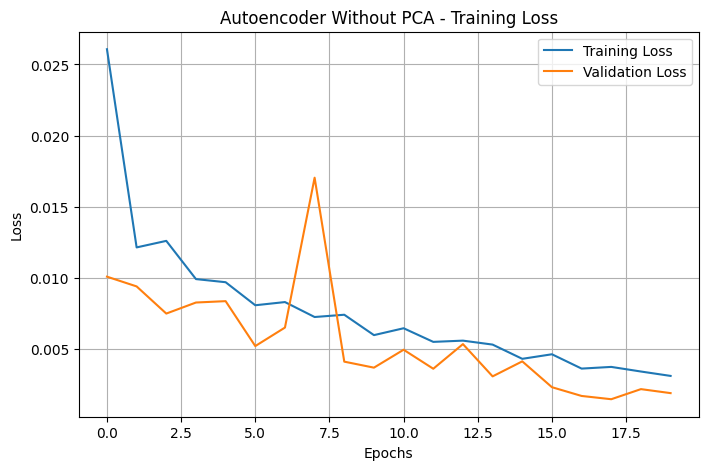

In [ ]:
# ======================================
# STEP B4: Plot training and validation loss
# ======================================

plt.figure(figsize=(8,5))
plt.plot(history_no_pca.history['loss'], label='Training Loss')
plt.plot(history_no_pca.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Autoencoder Without PCA - Training Loss")
plt.legend()
plt.grid(True)
plt.show()

**RECONSTRUCTION ERROR**

In [ ]:
# ======================================
# STEP B5: Compute training reconstruction error
# ======================================

X_train_pred_no_pca = ae_no_pca.predict(X_train_normal, verbose=0)
train_mse_no_pca = np.mean(np.square(X_train_normal - X_train_pred_no_pca), axis=1)

print("Sample training reconstruction errors:")
print(train_mse_no_pca[:10])

Sample training reconstruction errors:
[0.00023468 0.00035057 0.00034209 0.00038997 0.0010287  0.00035232
 0.00031429 0.00033997 0.00032669 0.00036959]


**ANOMALY THRESHOLD**

In [ ]:
# ======================================
# STEP B6: Set anomaly threshold
# ======================================

threshold_no_pca = np.percentile(train_mse_no_pca, 95)

print("Reconstruction error threshold (Without PCA):", threshold_no_pca)

Reconstruction error threshold (Without PCA): 0.0038011512664760092


**PREDICTION ON TEST DATA**

In [ ]:
# ======================================
# STEP B7: Predict anomalies on test data
# ======================================

X_test_pred_no_pca = ae_no_pca.predict(X_test_scaled, verbose=0)
mse_no_pca = np.mean(np.square(X_test_scaled - X_test_pred_no_pca), axis=1)

y_pred_no_pca = (mse_no_pca > threshold_no_pca).astype(int)

print("Predicted anomalies:", np.sum(y_pred_no_pca))
print("Actual anomalies   :", np.sum(y_test))

Predicted anomalies: 14438
Actual anomalies   : 7500


**EVALUATION**

In [ ]:
# ======================================
# STEP B8: Evaluate Autoencoder without PCA
# ======================================

acc_no_pca = accuracy_score(y_test, y_pred_no_pca) * 100
prec_no_pca = precision_score(y_test, y_pred_no_pca, zero_division=0) * 100
rec_no_pca = recall_score(y_test, y_pred_no_pca, zero_division=0) * 100
f1_no_pca = f1_score(y_test, y_pred_no_pca, zero_division=0) * 100
roc_no_pca = roc_auc_score(y_test, mse_no_pca) * 100

print("=====================================")
print("MODEL 1: AUTOENCODER WITHOUT PCA")
print("=====================================")
print("Threshold :", round(threshold_no_pca, 6))
print("Accuracy  :", round(acc_no_pca, 2), "%")
print("Precision :", round(prec_no_pca, 2), "%")
print("Recall    :", round(rec_no_pca, 2), "%")
print("F1 Score  :", round(f1_no_pca, 2), "%")
print("ROC AUC   :", round(roc_no_pca, 2), "%")

MODEL 1: AUTOENCODER WITHOUT PCA
Threshold : 0.003801
Accuracy  : 95.25 %
Precision : 51.3 %
Recall    : 98.75 %
F1 Score  : 67.52 %
ROC AUC   : 99.47 %


**CONFUSION MATRIX**

In [ ]:
# ======================================
# STEP B9: Confusion Matrix
# ======================================

cm_no_pca = confusion_matrix(y_test, y_pred_no_pca)
print("Confusion Matrix:\n", cm_no_pca)

Confusion Matrix:
 [[135467   7032]
 [    94   7406]]


**ROC CURVE

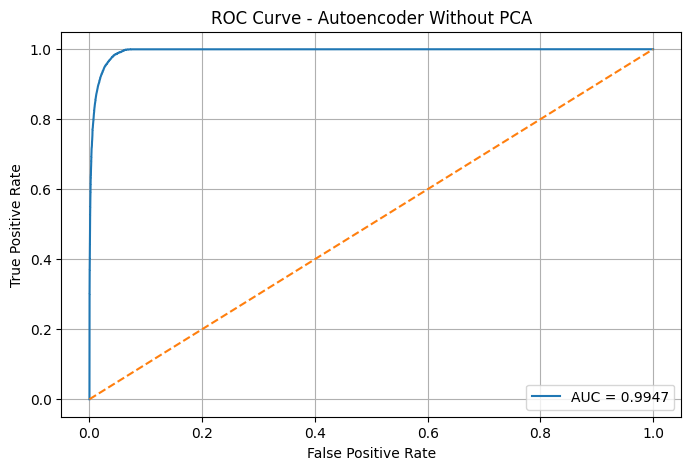

In [ ]:
# ======================================
# STEP B10: ROC Curve
# ======================================

fpr_no_pca, tpr_no_pca, _ = roc_curve(y_test, mse_no_pca)

plt.figure(figsize=(8,5))
plt.plot(fpr_no_pca, tpr_no_pca, label=f"AUC = {roc_no_pca/100:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Autoencoder Without PCA")
plt.legend()
plt.grid(True)
plt.show()

**MODEL 2: PCA WITH AUTOENCODER**

In [ ]:
# ======================================
# SECTION C: PCA + Autoencoder
# ======================================

# Reduce 6 features to 3 principal components
pca_exp = PCA(n_components=3)

X_train_pca = pca_exp.fit_transform(X_train_scaled)
X_test_pca = pca_exp.transform(X_test_scaled)

print("Original train shape:", X_train_scaled.shape)
print("PCA train shape     :", X_train_pca.shape)
print("Original test shape :", X_test_scaled.shape)
print("PCA test shape      :", X_test_pca.shape)

Original train shape: (349997, 6)
PCA train shape     : (349997, 3)
Original test shape : (149999, 6)
PCA test shape      : (149999, 3)


**EXPLAINED VARIENCE**

In [ ]:
# ======================================
# STEP C2: Explained variance by PCA
# ======================================

explained_variance = pca_exp.explained_variance_ratio_
total_variance = np.sum(explained_variance)

print("Explained Variance Ratio:", explained_variance)
print("Total Explained Variance:", round(total_variance * 100, 2), "%")

Explained Variance Ratio: [0.55946228 0.27334996 0.10912082]
Total Explained Variance: 94.19 %


**TRAINING ON NORMAL**

In [ ]:
# ======================================
# STEP C3: Select normal PCA training samples
# ======================================

X_train_pca_normal = X_train_pca[y_train == 0]

print("Normal PCA training samples shape:", X_train_pca_normal.shape)

Normal PCA training samples shape: (332498, 3)


**BUILD PCA + AUTOENCODER**

In [ ]:
# ======================================
# STEP C4: Build Autoencoder with PCA input
# ======================================

input_dim_pca = X_train_pca_normal.shape[1]

ae_pca = Sequential([
    Input(shape=(input_dim_pca,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(input_dim_pca, activation='linear')
])

ae_pca.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

ae_pca.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471 (1.84 KB)

 Trainable params: 471 (1.84 KB)

 Non-trainable params: 0 (0.00 B)

**TRAINING

In [ ]:
# ======================================
# STEP C5: Train PCA Autoencoder
# ======================================

history_pca = ae_pca.fit(
    X_train_pca_normal, X_train_pca_normal,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 0.0244 - val_loss: 0.0050
Epoch 2/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - loss: 0.0033 - val_loss: 3.8192e-04
Epoch 3/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.0010 - val_loss: 6.5962e-05
Epoch 4/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: 0.0018 - val_loss: 1.5018e-04
Epoch 5/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 0.0022 - val_loss: 1.2327e-04
Epoch 6/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 0.0012 - val_loss: 2.2160e-05
Epoch 7/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 6.3237e-04 - val_loss: 2.5509e-05
Epoch 8/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 0.0012 - val_loss: 1.7909e-05
Epoch 9/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 8.7419e-04 - val_loss: 0.0052
Epoch 10/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 5.6204e-04 - val_loss: 1.0508e-04
Epoch 11/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0

**Plot PCA Training Loss**

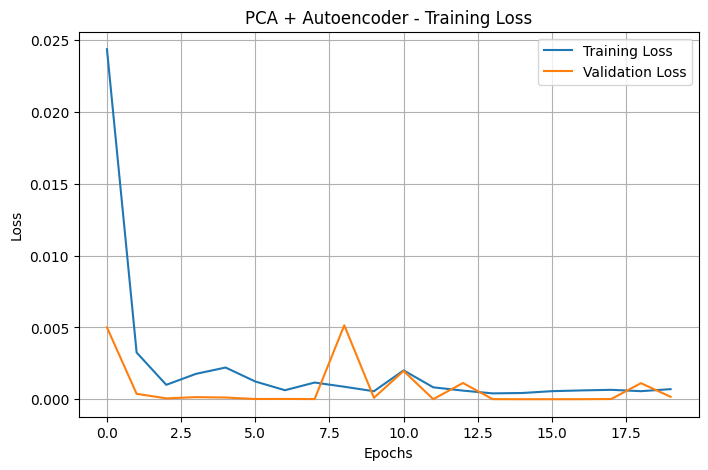

In [ ]:
# ======================================
# STEP C6: Plot training and validation loss
# ======================================

plt.figure(figsize=(8,5))
plt.plot(history_pca.history['loss'], label='Training Loss')
plt.plot(history_pca.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("PCA + Autoencoder - Training Loss")
plt.legend()
plt.grid(True)
plt.show()

**RECONSTRUCTION ERROR**

In [ ]:
# ======================================
# STEP C7: Compute training reconstruction error
# ======================================

X_train_pred_pca = ae_pca.predict(X_train_pca_normal, verbose=0)
train_mse_pca = np.mean(np.square(X_train_pca_normal - X_train_pred_pca), axis=1)

print("Sample PCA training reconstruction errors:")
print(train_mse_pca[:10])

Sample PCA training reconstruction errors:
[6.74709786e-06 8.27849585e-06 1.38511862e-05 5.04684626e-06
 1.00212493e-04 1.32394391e-05 1.40051778e-05 3.99044102e-05
 3.62774979e-05 2.04815474e-05]


**ANOMALY THRESHOLD**

In [ ]:
# ======================================
# STEP C8: Set anomaly threshold
# ======================================

threshold_pca = np.percentile(train_mse_pca, 95)

print("Reconstruction error threshold (PCA + AE):", threshold_pca)

Reconstruction error threshold (PCA + AE): 0.00024022744207208483


**PREDICTION**

In [ ]:
# ======================================
# STEP C9: Predict anomalies on PCA test data
# ======================================

X_test_pred_pca = ae_pca.predict(X_test_pca, verbose=0)
mse_pca = np.mean(np.square(X_test_pca - X_test_pred_pca), axis=1)

y_pred_pca = (mse_pca > threshold_pca).astype(int)

print("Predicted anomalies:", np.sum(y_pred_pca))
print("Actual anomalies   :", np.sum(y_test))

Predicted anomalies: 14245
Actual anomalies   : 7500


**EVALUATION**

In [ ]:
# ======================================
# STEP C10: Evaluate PCA + Autoencoder
# ======================================

acc_pca = accuracy_score(y_test, y_pred_pca) * 100
prec_pca = precision_score(y_test, y_pred_pca, zero_division=0) * 100
rec_pca = recall_score(y_test, y_pred_pca, zero_division=0) * 100
f1_pca = f1_score(y_test, y_pred_pca, zero_division=0) * 100
roc_pca = roc_auc_score(y_test, mse_pca) * 100

print("=====================================")
print("MODEL 2: PCA + AUTOENCODER")
print("=====================================")
print("Threshold :", round(threshold_pca, 6))
print("Accuracy  :", round(acc_pca, 2), "%")
print("Precision :", round(prec_pca, 2), "%")
print("Recall    :", round(rec_pca, 2), "%")
print("F1 Score  :", round(f1_pca, 2), "%")
print("ROC AUC   :", round(roc_pca, 2), "%")

MODEL 2: PCA + AUTOENCODER
Threshold : 0.00024
Accuracy  : 95.0 %
Precision : 49.98 %
Recall    : 94.93 %
F1 Score  : 65.49 %
ROC AUC   : 99.06 %


**CONFUSION MATRIX**

In [ ]:
# ======================================
# STEP C11: Confusion Matrix
# ======================================

cm_pca = confusion_matrix(y_test, y_pred_pca)
print("Confusion Matrix:\n", cm_pca)

Confusion Matrix:
 [[135374   7125]
 [   380   7120]]


**ROC CURVE**

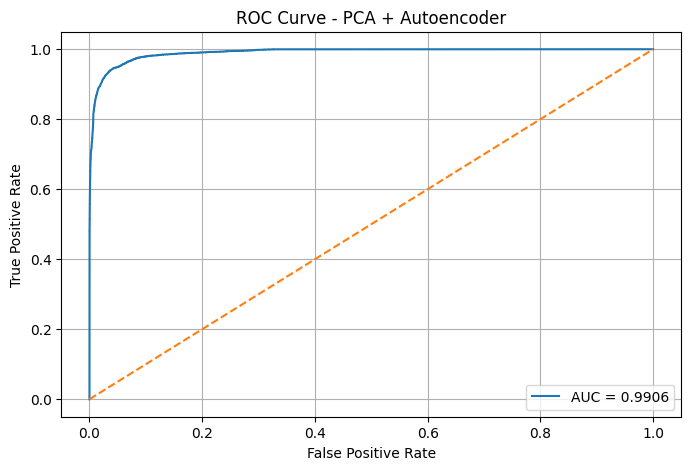

In [ ]:
# ======================================
# STEP C12: ROC Curve
# ======================================

fpr_pca, tpr_pca, _ = roc_curve(y_test, mse_pca)

plt.figure(figsize=(8,5))
plt.plot(fpr_pca, tpr_pca, label=f"AUC = {roc_pca/100:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PCA + Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

**MODEL3: LSTM AUTOENCODER**

In [ ]:
# ======================================
# SECTION D: LSTM Autoencoder
# ======================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# STEP D1: Reshape data for LSTM
# -------------------------------
# LSTM expects [samples, timesteps, features]
# Here, each sample has 1 timestep and N features (6 engineered features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print("LSTM Train shape:", X_train_lstm.shape)
print("LSTM Test shape :", X_test_lstm.shape)

# -------------------------------
# STEP D2: Build LSTM Autoencoder
# -------------------------------
input_dim = X_train_lstm.shape[2]  # number of features
timesteps = X_train_lstm.shape[1]

lstm_ae = Sequential([
    LSTM(32, activation='relu', input_shape=(timesteps, input_dim), return_sequences=False),
    RepeatVector(timesteps),
    LSTM(32, activation='relu', return_sequences=True),
    TimeDistributed(Dense(input_dim))
])

lstm_ae.compile(optimizer='adam', loss='mse')
lstm_ae.summary()

LSTM Train shape: (349997, 1, 6)
LSTM Test shape : (149999, 1, 6)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 6)           │           198 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,510 (52.77 KB)

 Trainable params: 13,510 (52.77 KB)

 Non-trainable params: 0 (0.00 B)

**TRAINING**

In [ ]:
# -------------------------------
# STEP D3: Train LSTM Autoencoder
# -------------------------------
history_lstm = lstm_ae.fit(
    X_train_lstm[y_train==0],  # train only on normal samples
    X_train_lstm[y_train==0],
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - loss: 0.0153 - val_loss: 8.8882e-04
Epoch 2/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - loss: 0.0063 - val_loss: 7.6900e-04
Epoch 3/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - loss: 0.0079 - val_loss: 2.0377e-04
Epoch 4/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.0047 - val_loss: 0.0012
Epoch 5/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 6/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 0.0029 - val_loss: 5.2887e-04
Epoch 7/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 8/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 9/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: 0.0042 - val_loss: 0.0014
Epoch 10/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 0.0022 - val_loss: 3.2896e-04
Epoch 11/20
8313/8313 ━━━━━━━━━━━━━━━━━━━━ 68s 5ms/step - loss: 0.0024 - val_loss: 0.0037

**PLOT TRAINING LOSS**

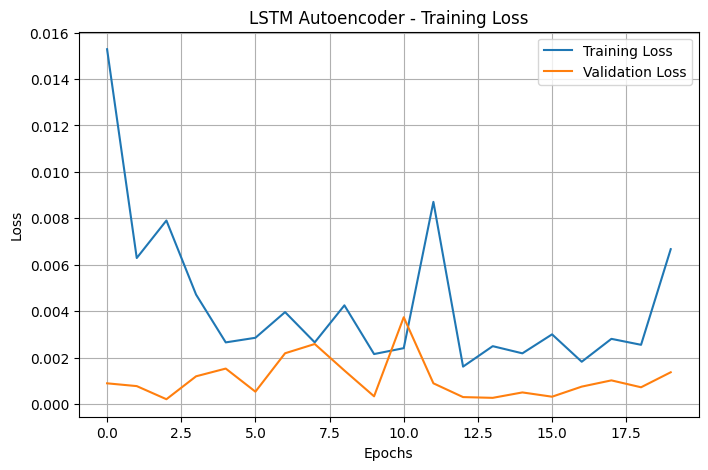

In [45]:
# -------------------------------
# STEP D4: Plot training loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("LSTM Autoencoder - Training Loss")
plt.legend()
plt.grid(True)
plt.show()

**PREDICTION**

In [46]:
# -------------------------------
# STEP D5: Predict on Test Data
# -------------------------------
X_test_pred_lstm = lstm_ae.predict(X_test_lstm, verbose=0)
mse_lstm = np.mean(np.square(X_test_lstm - X_test_pred_lstm), axis=(1,2))

# Threshold based on 95th percentile of normal training reconstruction error
train_pred_lstm = lstm_ae.predict(X_train_lstm[y_train==0], verbose=0)
train_mse_lstm = np.mean(np.square(X_train_lstm[y_train==0] - train_pred_lstm), axis=(1,2))
threshold_lstm = np.percentile(train_mse_lstm, 95)

y_pred_lstm = (mse_lstm > threshold_lstm).astype(int)



EVALUATION MATRIX

In [47]:
# -------------------------------
# STEP D6: Evaluate Metrics
# -------------------------------
acc_lstm = accuracy_score(y_test, y_pred_lstm) * 100
prec_lstm = precision_score(y_test, y_pred_lstm, zero_division=0) * 100
rec_lstm = recall_score(y_test, y_pred_lstm, zero_division=0) * 100
f1_lstm = f1_score(y_test, y_pred_lstm, zero_division=0) * 100
roc_lstm = roc_auc_score(y_test, mse_lstm) * 100

print("=====================================")
print("MODEL 3: LSTM AUTOENCODER")
print("=====================================")
print("Threshold :", round(threshold_lstm, 6))
print("Accuracy  :", round(acc_lstm, 2), "%")
print("Precision :", round(prec_lstm, 2), "%")
print("Recall    :", round(rec_lstm, 2), "%")
print("F1 Score  :", round(f1_lstm, 2), "%")
print("ROC AUC   :", round(roc_lstm, 2), "%")


MODEL 3: LSTM AUTOENCODER
Threshold : 0.000436
Accuracy  : 95.05 %
Precision : 50.25 %
Recall    : 93.45 %
F1 Score  : 65.36 %
ROC AUC   : 98.65 %


**CONFUSION MATRIX

In [48]:
# -------------------------------
# STEP D7: Confusion Matrix
# -------------------------------
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print("Confusion Matrix:\n", cm_lstm)



Confusion Matrix:
 [[135560   6939]
 [   491   7009]]


**ROC CURVE**

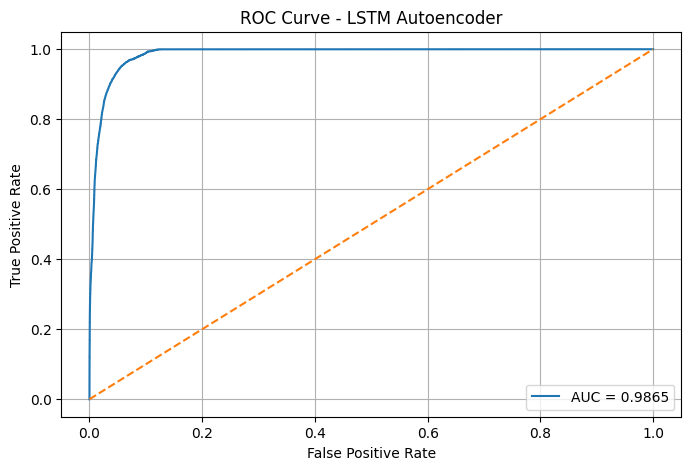

In [49]:
# -------------------------------
# STEP D8: ROC Curve
# -------------------------------
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, mse_lstm)

plt.figure(figsize=(8,5))
plt.plot(fpr_lstm, tpr_lstm, label=f"AUC = {roc_lstm/100:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

**FINAL COMPARISON TABLE**

In [50]:
# ======================================
# SECTION F: Final Comparison Table
# ======================================

import pandas as pd

# Create a final comparison table
comparison_df = pd.DataFrame({
    "Model": ["Autoencoder w/o PCA", "PCA + Autoencoder", "LSTM Autoencoder"],
    "Accuracy (%)": [round(acc_no_pca,2), round(acc_pca,2), round(acc_lstm,2)],
    "Precision (%)": [round(prec_no_pca,2), round(prec_pca,2), round(prec_lstm,2)],
    "Recall (%)": [round(rec_no_pca,2), round(rec_pca,2), round(rec_lstm,2)],
    "F1 Score (%)": [round(f1_no_pca,2), round(f1_pca,2), round(f1_lstm,2)],
    "ROC AUC (%)": [round(roc_no_pca,2), round(roc_pca,2), round(roc_lstm,2)]
})

# Sort by F1 Score or ROC AUC for best model visualization
comparison_df_sorted = comparison_df.sort_values(by="F1 Score (%)", ascending=False)

print("===== Final Comparison Table =====")
print(comparison_df_sorted)

# Optional: save to CSV for report
comparison_df_sorted.to_csv("model_comparison_table.csv", index=False)

===== Final Comparison Table =====
                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  \
0  Autoencoder w/o PCA         95.25          51.30       98.75         67.52   
1    PCA + Autoencoder         95.00          49.98       94.93         65.49   
2     LSTM Autoencoder         95.05          50.25       93.45         65.36   

   ROC AUC (%)  
0        99.47  
1        99.06  
2        98.65  


**SAVING BEST MODEL**

In [67]:
import joblib
import tensorflow as tf

# Determine best model based on F1 Score
best_model_name = comparison_df_sorted.iloc[0]['Model'].strip()
print("Best Model Selected:", best_model_name)

# Save best model
if best_model_name.lower() == "lstm autoencoder":
    lstm_ae.save("/content/best_model_lstm_ae.h5")
    print("LSTM Autoencoder saved as 'best_model_lstm_ae.h5'")
    use_pca = False

elif best_model_name.lower() == "pca + autoencoder":
    ae_pca.save("/content/best_model_pca_ae.h5")
    print("PCA + Autoencoder saved as 'best_model_pca_ae.h5'")
    use_pca = True

else:
    ae_no_pca.save("/content/best_model_ae_no_pca.h5")
    print("Autoencoder w/o PCA saved as 'best_model_ae_no_pca.h5'")
    use_pca = False

# Save preprocessing objects
joblib.dump(scaler_exp, "/content/scaler_exp.save")
if use_pca:
    joblib.dump(pca_exp, "/content/pca_exp.save")  # Only if PCA model is used

print("Preprocessing objects saved (scaler and PCA if needed).")

Best Model Selected: Autoencoder w/o PCA
Autoencoder w/o PCA saved as 'best_model_ae_no_pca.h5'
Preprocessing objects saved (scaler and PCA if needed).
